In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

# data (as pandas dataframes)
X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

# metadata
print(phiusiil_phishing_url_website.metadata)

# variable information
print(phiusiil_phishing_url_website.variables)

print(X)
print(y)
# y labels 1 or 0, 1 is legitimate, 0 is phishing

{'uci_id': 967, 'name': 'PhiUSIIL Phishing URL (Website)', 'repository_url': 'https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/967/data.csv', 'abstract': 'PhiUSIIL Phishing URL Dataset is a substantial dataset comprising 134,850 legitimate and 100,945 phishing URLs. Most of the URLs we analyzed, while constructing the dataset, are the latest URLs. Features are extracted from the source code of the webpage and URL. Features such as CharContinuationRate, URLTitleMatchScore, URLCharProb, and TLDLegitimateProb are derived from existing features.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 235795, 'num_features': 54, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['label'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2024, 'last_updated': 'Sun May 12 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

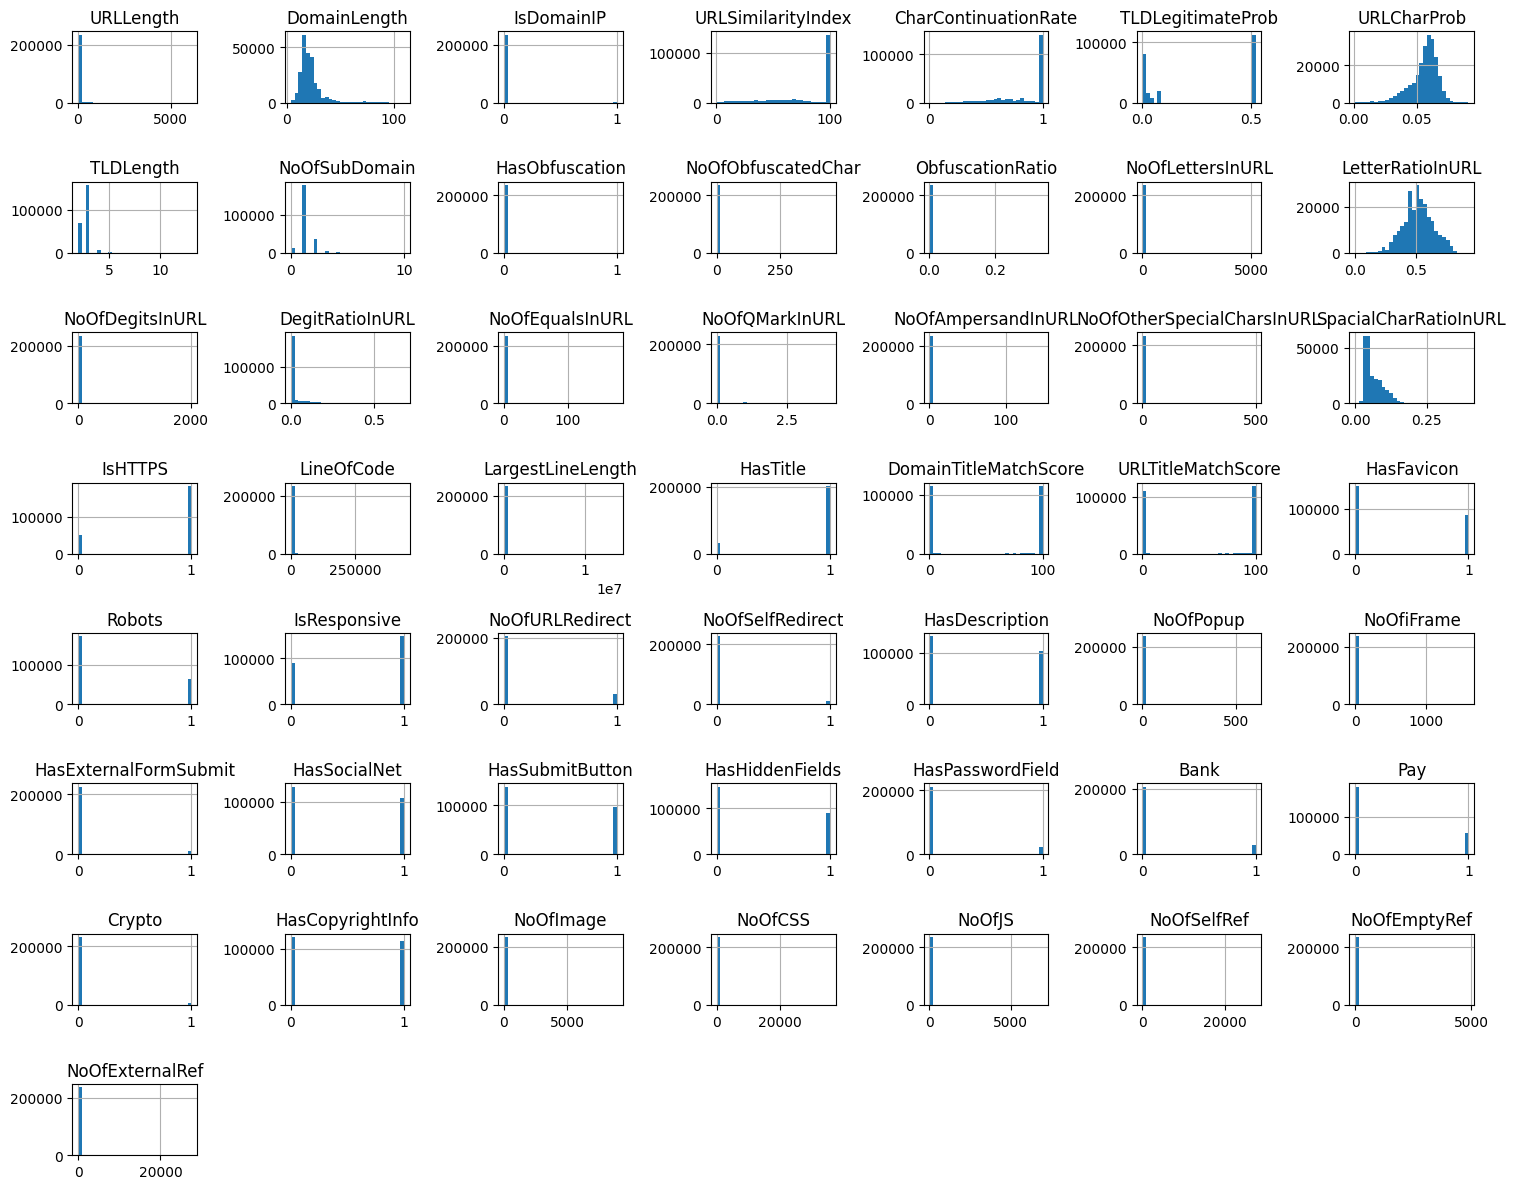

In [ ]:
X.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()



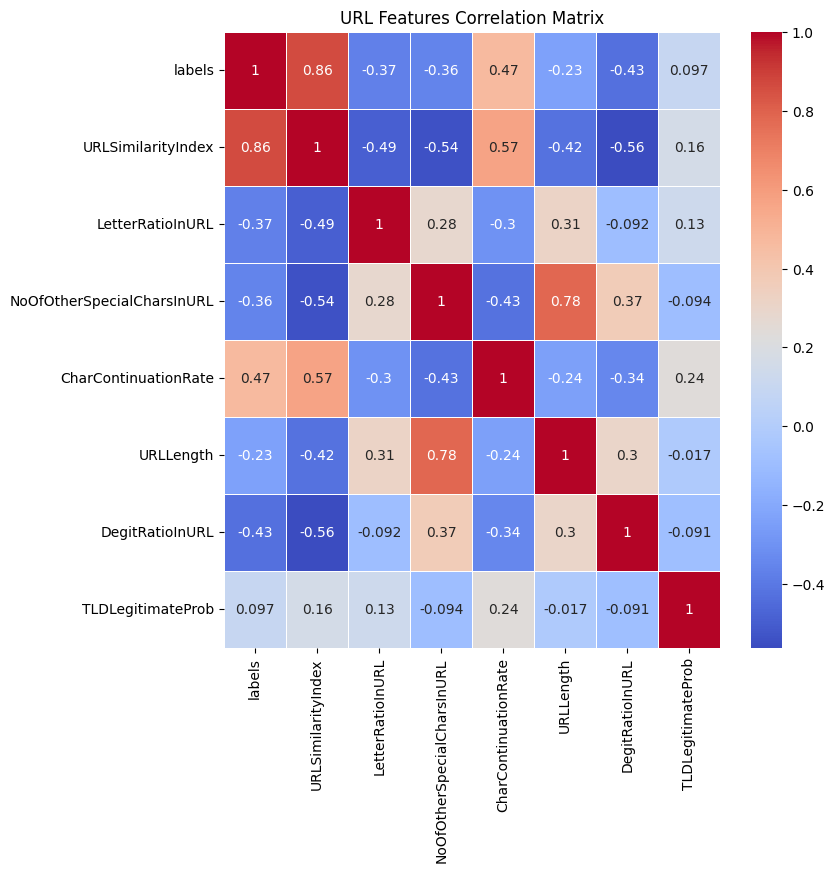

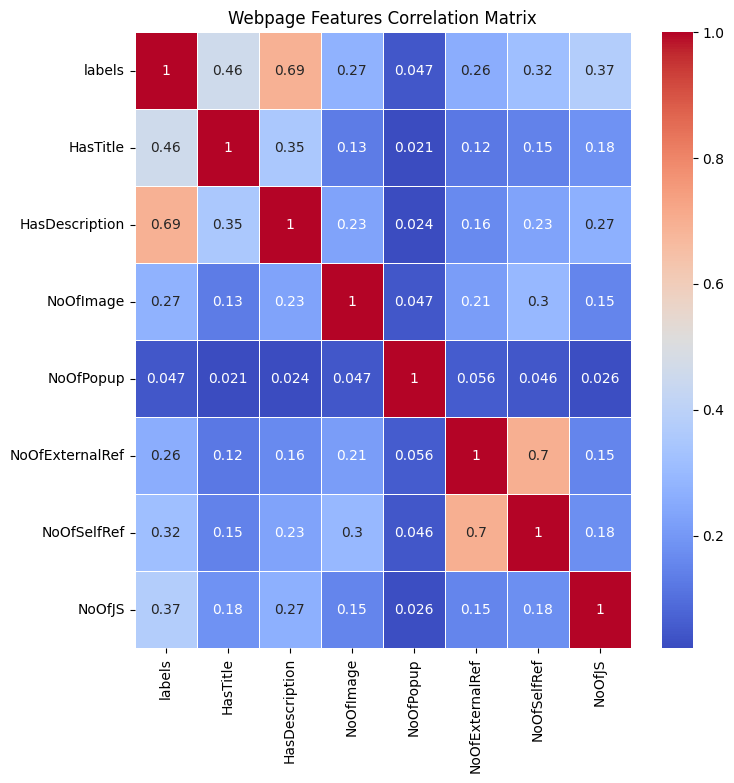

In [ ]:
data = X.copy()
data['labels'] = y
data_URL = data[['labels', 'URLSimilarityIndex', 'LetterRatioInURL', 'NoOfOtherSpecialCharsInURL', 'CharContinuationRate', 'URLLength', 'DegitRatioInURL', 'TLDLegitimateProb']]
data_website = data[['labels', 'HasTitle', 'HasDescription', 'NoOfImage', 'NoOfPopup', 'NoOfExternalRef', 'NoOfSelfRef', 'NoOfJS']]
# data_numeric = data.select_dtypes(include='number')
# correlation_matrix = data_numeric.corr()
# plt.figure(figsize=(50, 50))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()

data_numeric = data_URL.select_dtypes(include='number')
correlation_matrix = data_numeric.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('URL Features Correlation Matrix')
plt.show()

data_numeric = data_website.select_dtypes(include='number')
correlation_matrix = data_numeric.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Webpage Features Correlation Matrix')
plt.show()

<Axes: xlabel='labels', ylabel='URLSimilarityIndex'>

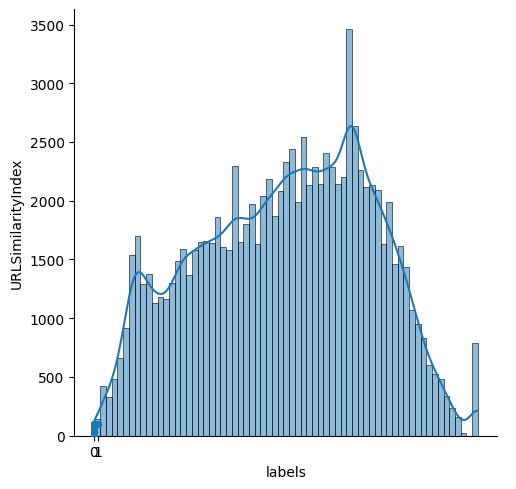

In [ ]:
sns.catplot(x='labels', y='URLSimilarityIndex', data=data)
phishingData = data[data['labels'] == 0]
legitimateData = data[data['labels'] == 1]
sns.histplot(x='URLSimilarityIndex', data=phishingData, label='Phishing', kde=True)
# sns.histplot(x='URLSimilarityIndex', data=legitimateData, label='Legitimate', kde=True)

<Axes: xlabel='labels', ylabel='DomainTitleMatchScore'>

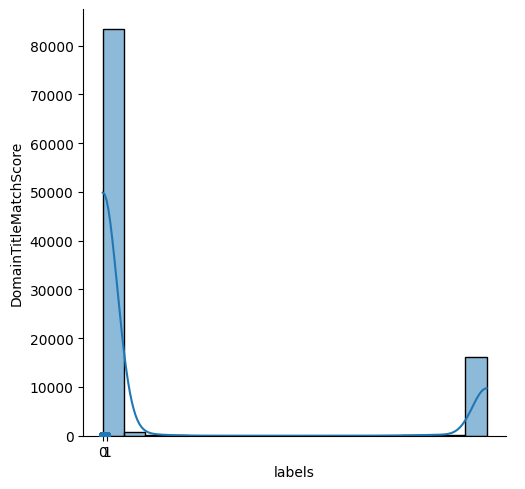

In [ ]:
sns.catplot(x='labels', y='DomainTitleMatchScore', data=data)
phishingData = data[data['labels'] == 0]
legitimateData = data[data['labels'] == 1]
sns.histplot(x='DomainTitleMatchScore', data=phishingData, label='Phishing', kde=True)
# sns.histplot(x='URLSimilarityIndex', data=legitimateData, label='Legitimate', kde=True)

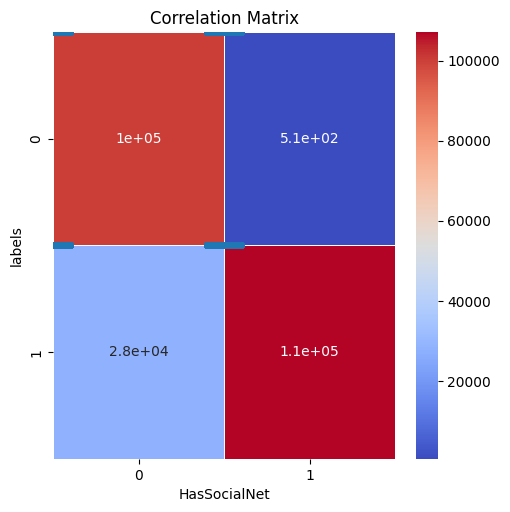

In [ ]:
sns.catplot(x='labels', y='HasSocialNet', data=data)
matrix = pd.crosstab(data['labels'], data['HasSocialNet'])
sns.heatmap(matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()
# sns.histplot(x='HasSocialNet', data=phishingData, label='Phishing', kde=True)
# sns.histplot(x='URLSimilarityIndex', data=legitimateData, label='Legitimate', kde=True)

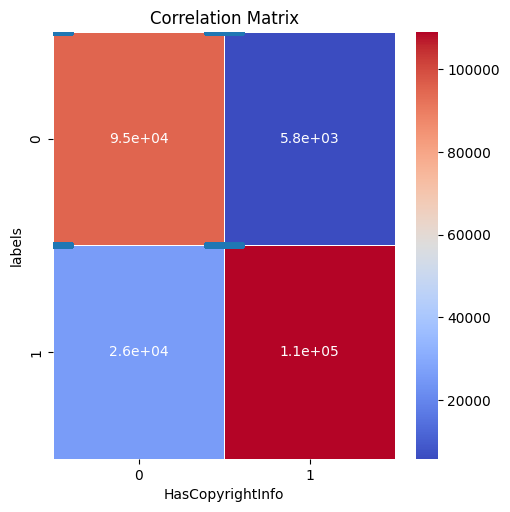

In [ ]:
sns.catplot(x='labels', y='HasCopyrightInfo', data=data)
matrix = pd.crosstab(data['labels'], data['HasCopyrightInfo'])
sns.heatmap(matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()
# sns.histplot(x='HasSocialNet', data=phishingData, label='Phishing', kde=True)
# sns.histplot(x='URLSimilarityIndex', data=legitimateData, label='Legitimate', kde=True)

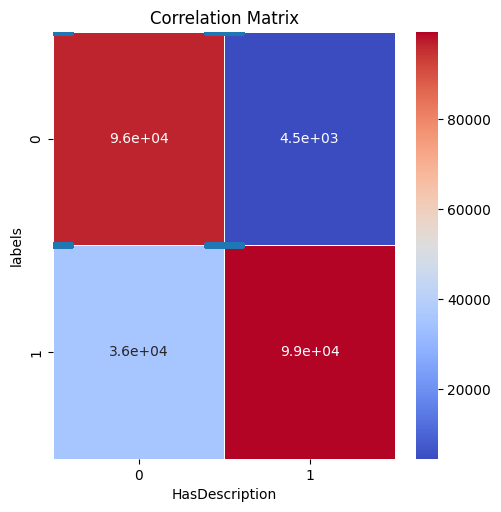

In [ ]:
sns.catplot(x='labels', y='HasDescription', data=data)
matrix = pd.crosstab(data['labels'], data['HasDescription'])
sns.heatmap(matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()
# sns.histplot(x='HasSocialNet', data=phishingData, label='Phishing', kde=True)
# sns.histplot(x='URLSimilarityIndex', data=legitimateData, label='Legitimate', kde=True)

In [ ]:
pip install scikit-learn

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

# data (as pandas dataframes)
#X = phiusiil_phishing_url_website.data.features[['URLSimilarityIndex', 'LetterRatioInURL', 'NoOfOtherSpecialCharsInURL', 'CharContinuationRate', 'URLLength', 'DegitRatioInURL', 'TLDLegitimateProb']]
X = phiusiil_phishing_url_website.data.features[['HasTitle', 'HasDescription', 'NoOfImage', 'NoOfPopup', 'NoOfExternalRef', 'NoOfSelfRef', 'NoOfJS']]
# X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

# Drop explicitly identified non-numeric columns
# X_train_numeric = X_train.drop(['URL', 'Domain', 'TLD'], axis=1) # Removed this line

# Identify and drop any remaining non-numeric columns
X_train_numeric = X_train.select_dtypes(include=np.number) # Modified to select only numeric columns


# Compute mutual information scores
mi_scores = mutual_info_classif(X_train_numeric, y_train.values.ravel(), discrete_features='auto', random_state=42)

# Put scores into a DataFrame
mi_df = pd.DataFrame({'Feature': X_train_numeric.columns, 'Score': mi_scores})
mi_df = mi_df.sort_values(by='Score', ascending=False).reset_index(drop=True)

print(mi_df)

           Feature     Score
0  NoOfExternalRef  0.561141
1        NoOfImage  0.541828
2      NoOfSelfRef  0.527131
3           NoOfJS  0.501521
4   HasDescription  0.301749
5         HasTitle  0.148209
6        NoOfPopup  0.024845


Random Forest Accuracy: 0.9933628787718145
Random Forest Precision: 0.9933899556868537
Random Forest Recall: 0.9950434621786572
Random Forest F1 Score: 0.9942160214358311
[[19945   179]
 [  134 26901]]


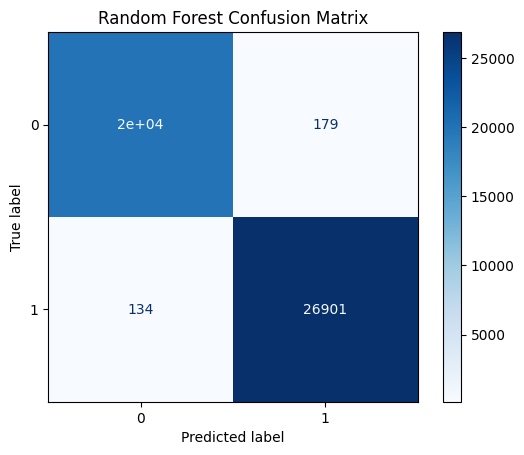

Decision Tree Accuracy: 0.9894823893636422
Tree Precision: 0.9908993377973437
Tree Recall: 0.9907527279452562
Tree F1 Score: 0.990826027447934
[[19878   246]
 [  250 26785]]


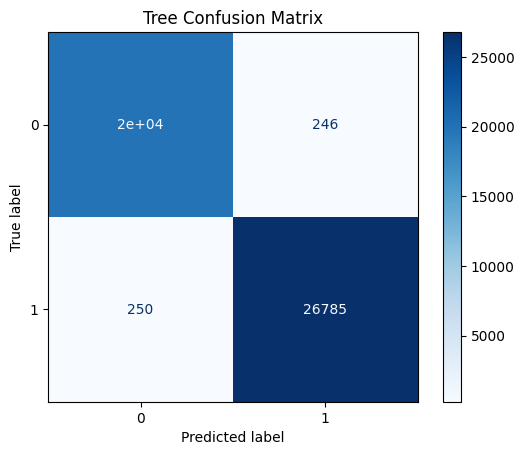

Logistic Regression Accuracy: 0.9822727369113
Logistic Regression Precision: 0.9911514378913426
Logistic Regression Recall: 0.9778065470686148
Logistic Regression F1 Score: 0.9844337690388411
[[19888   236]
 [  600 26435]]


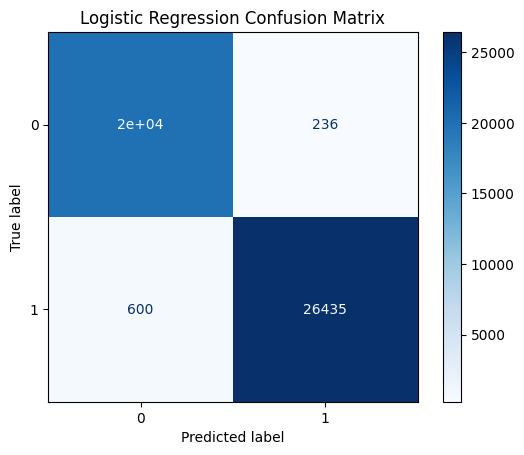

Nearest Neighbors Accuracy: 0.9901185351682605
Nearest Neighbors Precision: 0.9932791207159036
Nearest Neighbors Recall: 0.989458109857592
Nearest Neighbors F1 Score: 0.9913649334766335
[[19943   181]
 [  285 26750]]


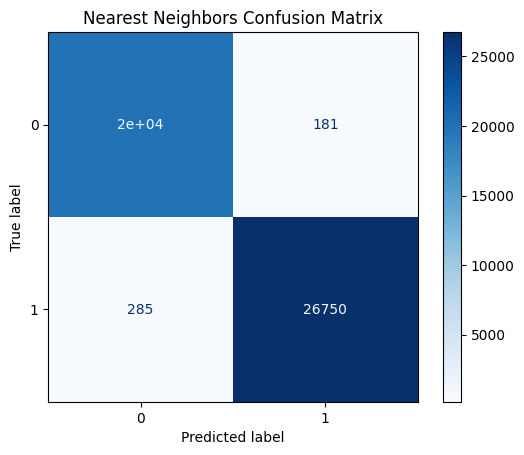

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

# Assume X = features, y = labels
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Remove redundant split

# Reshape X_train and X_test to be 2-dimensional
# X_train_reshaped = X_train.values.reshape(-1, 1) # Remove reshaping
# X_test_reshaped = X_test.values.reshape(-1, 1) # Remove reshaping
forest = RandomForestClassifier()
forest.fit(X_train, y_train.values.ravel())

y_pred = forest.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

print("Random Forest Precision:", precision_score(y_test, y_pred))
print("Random Forest Recall:", recall_score(y_test, y_pred))
print("Random Forest F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
print(cm)
plt.title("Random Forest Confusion Matrix")
plt.show()

tree = DecisionTreeClassifier(max_depth=6)
tree.fit(X_train, y_train.values.ravel())

y_pred = tree.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

print("Tree Precision:", precision_score(y_test, y_pred))
print("Tree Recall:", recall_score(y_test, y_pred))
print("Tree F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
print(cm)
plt.title("Tree Confusion Matrix")
plt.show()

log = LogisticRegression()
log.fit(X_train, y_train.values.ravel()) # Use X_train directly

y_pred = log.predict(X_test) # Use X_test directly
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

print("Logistic Regression Precision:", precision_score(y_test, y_pred))
print("Logistic Regression Recall:", recall_score(y_test, y_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
print(cm)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train.values.ravel()) # Use X_train directly

y_pred = knn.predict(X_test) # Use X_test directly
print("Nearest Neighbors Accuracy:", accuracy_score(y_test, y_pred))

print("Nearest Neighbors Precision:", precision_score(y_test, y_pred))
print("Nearest Neighbors Recall:", recall_score(y_test, y_pred))
print("Nearest Neighbors F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
print(cm)
plt.title("Nearest Neighbors Confusion Matrix")
plt.show()


MLP Accuracy: 0.9900761254479526
MLP Precision: 0.9894255922773664
MLP Recall: 0.9933049750323655
MLP F1 Score: 0.9913614884819847
[[19837   287]
 [  181 26854]]


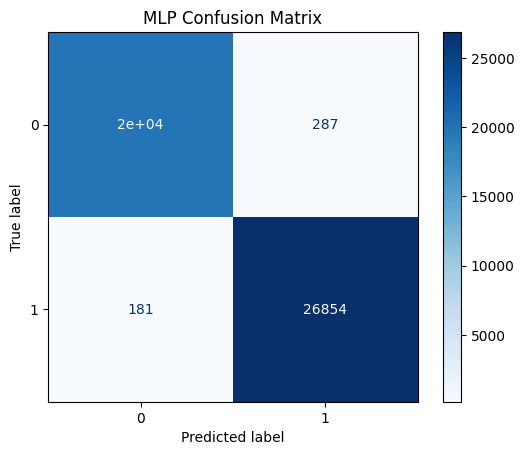

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=100, random_state=42)
mlp.fit(X_train, y_train.values.ravel())

y_pred = mlp.predict(X_test)
print("MLP Accuracy:", accuracy_score(y_test, y_pred))

print("MLP Precision:", precision_score(y_test, y_pred))
print("MLP Recall:", recall_score(y_test, y_pred))
print("MLP F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
print(cm)
plt.title("MLP Confusion Matrix")
plt.show()